# Modeling — Credit Risk Prediction

This notebook trains and compares 7 classification models — Logistic Regression, Decision Tree, 
Random Forest, XGBoost, and 3 neural network architectures — selects the best performer, tunes 
the classification threshold for the business context, and evaluates the final model on the 
held-out test set and the external Kaggle test set.

In [ ]:
# Import classical machine-learning models and search utilities.
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Import TensorFlow/Keras components for neural-network experiments.
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense, BatchNormalization
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
# Import metrics, plotting, persistence, and serialization utilities.
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

## Loading Preprocessed Data

Two parallel feature sets are loaded, matching the preprocessing pipeline: unscaled data with 
ordinal age encoding for tree-based models, and scaled data with one-hot age encoding for the 
linear model and neural networks.

`x_train` and `x_cv` are concatenated into `x_train_full` for hyperparameter search — 
`GridSearchCV`/`RandomizedSearchCV` performs its own internal cross-validation, so combining them 
gives a more robust estimate than relying on a single fixed CV split. `x_test` remains untouched 
until the final evaluation.

In [ ]:
# Load unscaled features for tree-based models.
x_train = pd.read_csv('../data/processed/x_train.csv')
x_cv = pd.read_csv('../data/processed/x_cv.csv')
x_test = pd.read_csv('../data/processed/x_test.csv')

# Load target labels for the three labeled splits.
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_cv = pd.read_csv('../data/processed/y_cv.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load scaled, one-hot encoded features for logistic regression and neural networks.
x_train_scaled = pd.read_csv('../data/processed/x_train_scaled.csv')
x_cv_scaled = pd.read_csv('../data/processed/x_cv_scaled.csv')
x_test_scaled = pd.read_csv('../data/processed/x_test_scaled.csv')

# Load the processed external test sets for final Kaggle predictions.
cs_test = pd.read_csv('../data/processed/cs_test_processed.csv')
cs_test_scaled = pd.read_csv('../data/processed/cs_test_scaled.csv')

# Combine training and CV data for nested cross-validated hyperparameter search.
x_train_full = np.concatenate((x_train, x_cv), axis=0)
x_train_sc_full = np.concatenate((x_train_scaled, x_cv_scaled), axis=0)
y_train_full = np.concatenate((y_train, y_cv), axis=0)

In [ ]:
# Store comparable validation metrics for every trained model.
scores = []

## Hyperparameter Search

A shared helper function runs `GridSearchCV` for Logistic Regression and Decision Tree (small, 
exhaustively searchable parameter grids), and `RandomizedSearchCV` for Random Forest and XGBoost 
(larger grids, where an exhaustive search would be too slow). Both are scored on ROC-AUC 
(primary metric, robust to class imbalance) and F1, with the model selected by ROC-AUC.

In [ ]:
# Run the appropriate cross-validated hyperparameter search for a model.
def build_search_cv(param_grid, model, x_train, y_train):
    # Use randomized search for larger ensemble parameter spaces.
    if isinstance(model, (XGBClassifier, RandomForestClassifier)):
        grid = RandomizedSearchCV(model, param_grid, scoring=['roc_auc', 'f1'], refit='roc_auc', n_jobs=6, random_state=42)
    else:
        # Exhaustively evaluate the smaller grids for linear and tree baselines.
        grid = GridSearchCV(model, param_grid, scoring=['roc_auc', 'f1'], refit='roc_auc')

    # Fit the search and select the configuration with the highest ROC-AUC.
    grid.fit(x_train, y_train)
    
    best_idx = grid.best_index_
    best_f1 = grid.cv_results_['mean_test_f1'][best_idx]

    # Report both tracked metrics for the selected configuration.
    print(grid.best_params_, grid.best_score_, 'F1:', best_f1)

    best_model = grid.best_estimator_
    scores.append({'model_name': type(model).__name__, 'roc_auc': grid.best_score_, 'f1': best_f1})

    return best_model

### Logistic Regression — baseline linear model

In [ ]:
# Search the solver choice for the scaled logistic-regression baseline.
lr_params = {'solver': ['liblinear', 'lbfgs', 'sag']}
lr_model = build_search_cv(lr_params, LogisticRegression(max_iter=1000, random_state=42), x_train_sc_full, y_train_full)

{'solver': 'sag'} 0.8390259041558087 F1: 0.22010378809542389


### Decision Tree

In [ ]:
# Search tree depth and split-size regularization for the decision tree.
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 7, 10, 15]}
dt_model = build_search_cv(dt_params, DecisionTreeClassifier(random_state=42), x_train_full, y_train_full)

{'max_depth': 5, 'min_samples_split': 2} 0.8473715608775569 F1: 0.2635706024906309


### Random Forest

In [ ]:
# Search ensemble size, depth, and minimum split size for Random Forest.
rf_params = {'n_estimators': [100, 200, 400], 'max_depth': [5, 10, 12, 20], 'min_samples_split':[2, 5, 10, 15]}
rf_model = build_search_cv(rf_params, RandomForestClassifier(random_state=42, n_jobs=1), x_train_full, y_train_full)

{'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 10} 0.8642045025083075 F1: 0.25939791425850994


### XGBoost

In [ ]:
# Search boosting rounds, learning rate, and tree depth for XGBoost.
xgbc_params = {'n_estimators': [100, 200, 400, 700], 'learning_rate': [0.01, 0.03, 0.05], 'max_depth': [5, 10, 12, 20]}
xgbc_model = build_search_cv(xgbc_params, XGBClassifier(random_state=42, n_jobs=1), x_train_full, y_train_full)

{'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.03} 0.865175895788991 F1: 0.2959923587655757


## Neural Networks

Three architectures are compared: two plain feed-forward networks of increasing depth 
(`model_1`, `model_2`), and a third (`model_3`) that adds `BatchNormalization` between layers, 
to check whether it improves training stability or final performance on this tabular dataset.

All output layers use a linear activation combined with `BinaryCrossentropy(from_logits=True)` 
for numerical stability — this means predictions from these models are raw logits, not 
probabilities, and require a `sigmoid` applied afterward.

In [ ]:
# Build three neural-network architectures with increasing complexity.
def build_models():
    # A compact two-hidden-layer feed-forward network.
    model_1 = Sequential([
        Dense(units=25, activation='relu'),
        Dense(units=15, activation='relu'),
        Dense(units=1, activation='linear'),
    ], name='model_1')

    # A deeper feed-forward network without normalization layers.
    model_2 = Sequential([
        Dense(units=30, activation='relu'),
        Dense(units=12, activation='relu'),
        Dense(units=7, activation='relu'),
        Dense(units=1, activation='linear'),
    ], name='model_2')

    # A deeper network that uses BatchNormalization to stabilize training.
    model_3 = Sequential([
        Dense(units=32, activation='relu'),
        BatchNormalization(),
        Dense(units=16, activation='relu'),
        BatchNormalization(),
        Dense(units=8, activation='relu'),
        BatchNormalization(),
        Dense(units=12, activation='relu'),
        BatchNormalization(),
        Dense(units=1, activation='linear'),
    ], name='model_3')

    # Return all candidate architectures for the training loop.
    models = [model_1, model_2, model_3]
    return models

`EarlyStopping` monitors validation AUC (not loss) and restores the best-performing weights, 
since AUC is the metric actually used to compare models — training is capped at 200 epochs, 
but stops earlier once validation AUC no longer improves.

In [ ]:
# Instantiate the candidate neural networks.
models_nn = build_models()

# Stop training when validation AUC stops improving and restore its best weights.
early_stop = EarlyStopping(
    monitor='val_AUC',      
    patience=20,            
    restore_best_weights=True,  
    mode='max'               
)

# Keep training histories for later curve comparisons.
histories = {}

for model in models_nn:
    # Use logits with binary cross-entropy for numerically stable training.
    model.compile(
        loss=BinaryCrossentropy(from_logits=True),
        optimizer=Adam(learning_rate=0.01),
        metrics=['AUC'] 
    )

    # Train on the scaled training set and monitor the held-out CV set.
    history = model.fit(
        x_train_scaled, y_train,      
        validation_data=(x_cv_scaled, y_cv),
        epochs=200,             
        batch_size=256,
        callbacks=[early_stop],
        verbose=0
    )

    histories[model.name] = history
    
    # Convert raw validation logits into probabilities for classification metrics.
    logits_cv = model.predict(x_cv_scaled, verbose=0).flatten()
    y_pred_proba_cv = tf.sigmoid(logits_cv).numpy()
    y_pred_class_cv = (y_pred_proba_cv >= 0.5).astype(int)

    # Evaluate the architecture on CV data using ROC-AUC and F1.
    cv_auc = roc_auc_score(y_cv, y_pred_proba_cv)
    cv_f1 = f1_score(y_cv, y_pred_class_cv)

    # Save each trained network for reuse without retraining.
    model.save(f'../models/{model.name}.keras')

    print(f'{model.name}: ROC-AUC={cv_auc:.4f}, F1={cv_f1:.4f}')
    scores.append({'model_name': model.name, 'model': model, 'roc_auc': cv_auc, 'f1': cv_f1})  

model_1: ROC-AUC=0.8568, F1=0.3324
model_2: ROC-AUC=0.8581, F1=0.3359
model_3: ROC-AUC=0.8575, F1=0.3685


Training curves for all three architectures, to check for signs of instability or overfitting 
that a single final metric wouldn't reveal.

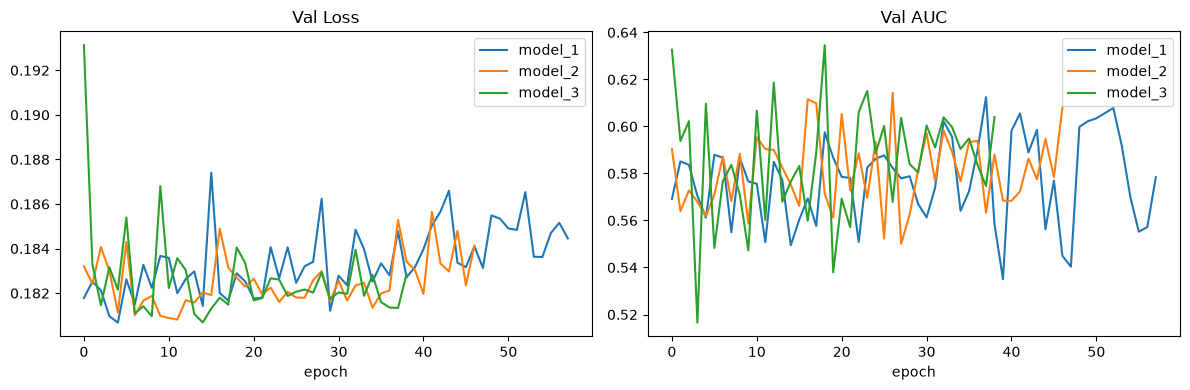

In [ ]:
# Compare validation loss and validation AUC trajectories across neural networks.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, history in histories.items():
    axes[0].plot(history.history['val_loss'], label=name)
    axes[1].plot(history.history['val_AUC'], label=name)  

# Label both panels and display the comparison.
axes[0].set_title('Val Loss')
axes[0].set_xlabel('epoch')
axes[1].set_title('Val AUC')
axes[1].set_xlabel('epoch')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

## Model Comparison

All 7 models — ranked by CV ROC-AUC.

In [ ]:
# Rank all candidate models by cross-validated ROC-AUC.
results_df = pd.DataFrame(scores).sort_values('roc_auc', ascending=False)
results_df

,model_name,roc_auc,f1,model
3,XGBClassifier,0.865176,0.295992,NaN
2,RandomForestClassifier,0.864205,0.259398,NaN
5,model_2,0.858144,0.335862,"<Sequential name=model_2, built=True>"
6,model_3,0.857526,0.368455,"<Sequential name=model_3, built=True>"
4,model_1,0.856792,0.332418,"<Sequential name=model_1, built=True>"
1,DecisionTreeClassifier,0.847372,0.263571,NaN
0,LogisticRegression,0.839026,0.220104,NaN


## Bias/Variance Check

Comparing train vs. CV ROC-AUC for each classical model reveals how much each one overfits, 
beyond what the CV score alone shows.

In [ ]:
# Compare training and CV AUC to quantify overfitting in classical models.
bias_variance_results = []

# Pair each classical model with the feature matrix used during training.
classical_models_bv = {
    'LogisticRegression': (lr_model, x_train_sc_full),
    'DecisionTreeClassifier': (dt_model, x_train_full),
    'RandomForestClassifier': (rf_model, x_train_full),
    'XGBClassifier': (xgbc_model, x_train_full),
}

for name, (model, x_data) in classical_models_bv.items():
    # Measure performance on the same data used for fitting.
    train_proba = model.predict_proba(x_data)[:, 1]
    train_auc = roc_auc_score(y_train_full, train_proba)

    # Retrieve the corresponding cross-validated score.
    cv_auc = results_df.loc[results_df['model_name'] == name, 'roc_auc'].values[0]

    # A larger train/CV gap indicates stronger overfitting.
    gap = train_auc - cv_auc
    bias_variance_results.append({
        'model_name': name,
        'train_auc': train_auc,
        'cv_auc': cv_auc,
        'gap': gap
    })

    print(f'{name}: train={train_auc:.4f}, cv={cv_auc:.4f}, gap={gap:.4f}')

# Sort models by the size of their generalization gap.
bias_variance_df = pd.DataFrame(bias_variance_results).sort_values('gap', ascending=False)
bias_variance_df

LogisticRegression: train=0.8396, cv=0.8390, gap=0.0005
DecisionTreeClassifier: train=0.8504, cv=0.8474, gap=0.0030
RandomForestClassifier: train=0.8934, cv=0.8642, gap=0.0292
XGBClassifier: train=0.8913, cv=0.8652, gap=0.0262


,model_name,train_auc,cv_auc,gap
2,RandomForestClassifier,0.893425,0.864205,0.029220
3,XGBClassifier,0.891346,0.865176,0.026170
1,DecisionTreeClassifier,0.850418,0.847372,0.003046
0,LogisticRegression,0.839558,0.839026,0.000532


Random Forest and XGBoost show a noticeably larger train/CV gap than Logistic Regression and the 
single Decision Tree — expected, since ensemble methods have more capacity to fit training data 
closely. The gap is still moderate (under 0.03) for both, suggesting the hyperparameter search 
already applied reasonable regularization (limited `max_depth`, `min_samples_split`) rather than 
letting the models overfit freely.

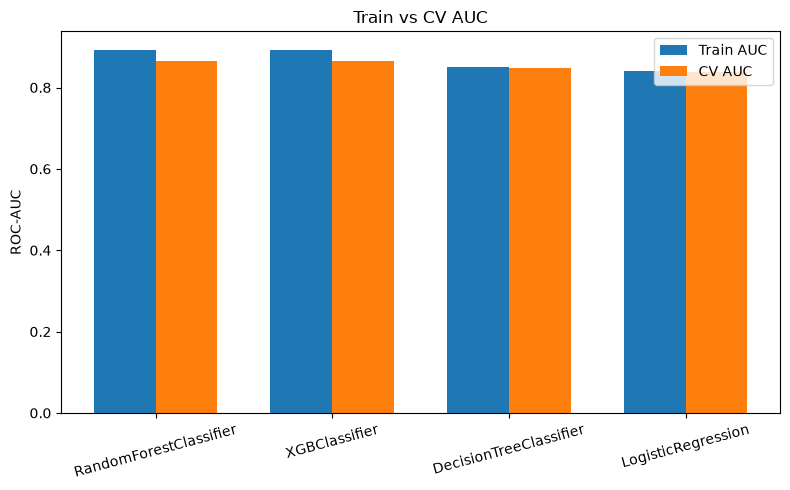

In [ ]:
# Visualize train-versus-CV ROC-AUC for the classical models.
plt.figure(figsize=(8, 5))
x_pos = range(len(bias_variance_df))

# Draw paired bars so the generalization gap is easy to compare.
plt.bar(x_pos, bias_variance_df['train_auc'], width=0.35, label='Train AUC', align='edge')
plt.bar([p + 0.35 for p in x_pos], bias_variance_df['cv_auc'], width=0.35, label='CV AUC', align='edge')

plt.xticks([p + 0.35 for p in x_pos], bias_variance_df['model_name'], rotation=15)
plt.ylabel('ROC-AUC')
plt.title('Train vs CV AUC')
plt.legend()
plt.tight_layout()
plt.show()

CV ROC-AUC across all 7 models, visualized.

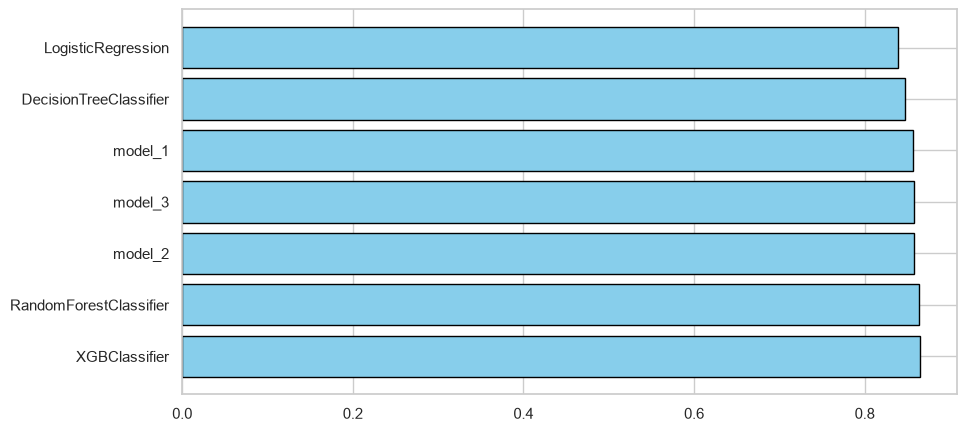

In [ ]:
# Plot cross-validated ROC-AUC for all candidate models.
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

bars = plt.barh(
    results_df["model_name"], results_df["roc_auc"], color="skyblue", edgecolor="black"
)

## Threshold Selection

XGBoost is selected as the final model — highest CV ROC-AUC (0.865) among all candidates, with a 
moderate train/CV gap.

The default classification threshold (0.5) is not appropriate for this problem: in credit risk, 
a false negative (missing an actual defaulter) is more costly than a false positive (an 
unnecessarily cautious decision on a reliable borrower). The threshold is tuned on **`x_cv`**, 
not `x_test` — treating it as a model selection decision, exactly like a hyperparameter, keeps 
`x_test` untouched for a single, unbiased final evaluation.

In [ ]:
# Generate XGBoost probabilities on the CV set for threshold selection.
y_predict_proba_cv = xgbc_model.predict_proba(x_cv)[:, 1]

# Compare recall, precision, and F1 across business-relevant thresholds.
for t in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
    y_pred_t = (y_predict_proba_cv >= t).astype(int)
    print(f'threshold={t}: recall={recall_score(y_cv, y_pred_t):.3f}, precision={precision_score(y_cv, y_pred_t):.3f}, f1={f1_score(y_cv, y_pred_t):.3f}')

threshold=0.15: recall=0.637, precision=0.367, f1=0.466
threshold=0.2: recall=0.571, precision=0.434, f1=0.493
threshold=0.25: recall=0.508, precision=0.480, f1=0.494
threshold=0.3: recall=0.449, precision=0.522, f1=0.483
threshold=0.35: recall=0.394, precision=0.575, f1=0.468
threshold=0.4: recall=0.332, precision=0.612, f1=0.431


F1 peaks around threshold 0.2–0.25. Threshold 0.2 is selected: it lies within the F1-optimal 
range while leaning toward higher recall (0.57 vs. 0.51 at 0.25), consistent with the priority 
of not missing defaulters.

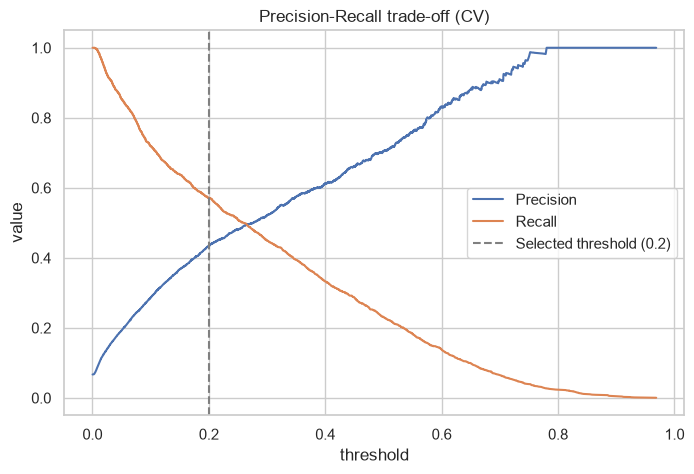

In [ ]:
# Compute precision and recall over the full range of possible CV thresholds.

precisions, recalls, pr_thresholds = precision_recall_curve(y_cv, y_predict_proba_cv)

# Plot the precision-recall trade-off and mark the selected threshold.
plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, precisions[:-1], label='Precision')
plt.plot(pr_thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.2, color='gray', linestyle='--', label='Selected threshold (0.2)')
plt.xlabel('threshold')
plt.ylabel('value')
plt.title('Precision-Recall trade-off (CV)')
plt.legend()
plt.show()

## Final Evaluation on the Test Set

With the model and threshold now fixed, `x_test` is used for the first and only time in this 
notebook, to obtain an unbiased estimate of real-world performance.

In [ ]:
# Generate final XGBoost probabilities on the untouched test set.
y_predict_proba_test = xgbc_model.predict_proba(x_test)[:, 1]
# Apply the threshold selected using CV data.
y_predict_class_test = (y_predict_proba_test >= 0.2).astype(int)

# Evaluate ranking quality and thresholded classification quality separately.
test_auc = roc_auc_score(y_test, y_predict_proba_test)
test_f1 = f1_score(y_test, y_predict_class_test)

print(f'Test ROC-AUC: {test_auc:.4f}')
print(f'Test F1: {test_f1:.4f}')

Test ROC-AUC: 0.8618
Test F1: 0.4344


In [ ]:
# Print precision, recall, and F1 for each class on the final test predictions.
print(classification_report(y_test, y_predict_class_test))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27877
           1       0.38      0.51      0.43      2002

    accuracy                           0.91     29879
   macro avg       0.67      0.73      0.69     29879
weighted avg       0.92      0.91      0.92     29879



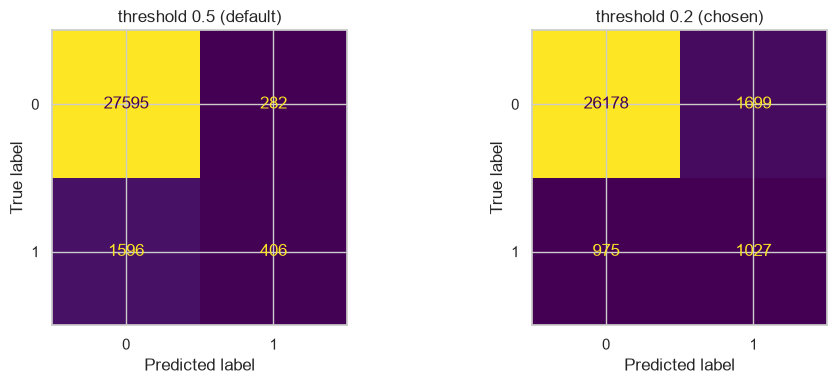

In [ ]:
# Compare confusion matrices at the default and selected thresholds.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Create class predictions under both decision policies.
y_pred_default = (y_predict_proba_test >= 0.5).astype(int)
y_pred_chosen = (y_predict_proba_test >= 0.2).astype(int)

# Calculate confusion matrices for direct comparison.
cm_default = confusion_matrix(y_test, y_pred_default)
cm_chosen = confusion_matrix(y_test, y_pred_chosen)

ConfusionMatrixDisplay(cm_default).plot(ax=axes[0], colorbar=False)
axes[0].set_title('threshold 0.5 (default)')

ConfusionMatrixDisplay(cm_chosen).plot(ax=axes[1], colorbar=False)
axes[1].set_title('threshold 0.2 (chosen)')

# Arrange both panels and display the comparison.
plt.tight_layout()
plt.show()

At the default threshold (0.5), the model would only catch 21% of actual defaulters. At the 
selected threshold (0.2), recall on the default class rises to 51%, at the cost of lower 
precision (0.38) — a deliberate trade-off given the asymmetric cost of the two error types.

## Feature Importance

Top features by XGBoost's built-in importance score. Notably, the three "days past due" columns 
and `RevolvingUtilizationOfUnsecuredLines` — flagged as the strongest signals back in the EDA and 
confirmed again in both mutual information checks — remain the top predictors here, showing 
consistency across independent analysis methods throughout the project.

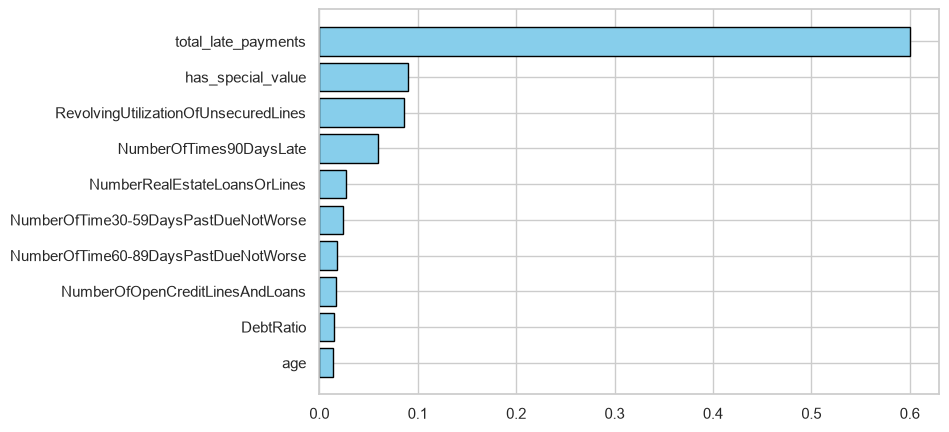

In [ ]:
# Extract XGBoost's built-in importance score for every feature.
xgbc_features = xgbc_model.feature_importances_
feature_names = x_train.columns

# Keep and sort the ten most important features for visualization.
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": xgbc_features})
importance_df = importance_df.sort_values(by="Importance", ascending=True).tail(10)

# Plot the selected feature-importance scores.
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

bars = plt.barh(
    importance_df["Feature"], importance_df["Importance"], color="skyblue", edgecolor="black"
)

## ROC Curve Comparison

All models plotted together on CV data. XGBoost, Random Forest, and the best neural network 
cluster closely near the top, while Logistic Regression and the Decision Tree sit visibly lower 
— consistent with the mutual information analysis in preprocessing, which suggested several key 
features have a non-linear relationship with the target that tree-based/neural models capture 
more naturally than a linear model.

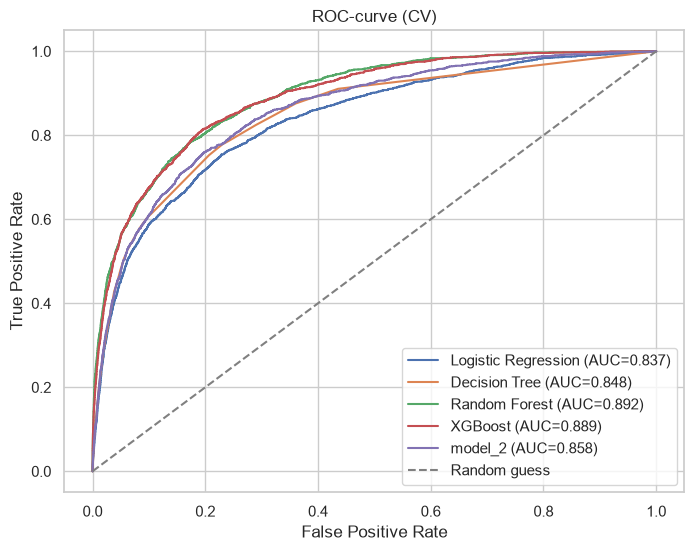

In [ ]:
# Plot ROC curves for classical models and the selected neural network on CV data.
plt.figure(figsize=(8, 6))

# Pair each classical model with the matching CV feature representation.
classical_models = {
    'Logistic Regression': (lr_model, x_cv_scaled), 
    'Decision Tree': (dt_model, x_cv),
    'Random Forest': (rf_model, x_cv),
    'XGBoost': (xgbc_model, x_cv),
}

for name, (model, x_cv_data) in classical_models.items():
    # Convert model probabilities into an ROC curve and AUC value.
    proba = model.predict_proba(x_cv_data.values)[:, 1]
    fpr, tpr, _ = roc_curve(y_cv, proba)
    auc = roc_auc_score(y_cv, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

# Add the strongest neural-network candidate to the same comparison.
best_nn = models_nn[1]  
logits_cv = best_nn.predict(x_cv_scaled, verbose=0).flatten()
proba_nn = tf.sigmoid(logits_cv).numpy()
fpr_nn, tpr_nn, _ = roc_curve(y_cv, proba_nn)
auc_nn = roc_auc_score(y_cv, proba_nn)
plt.plot(fpr_nn, tpr_nn, label=f'{best_nn.name} (AUC={auc_nn:.3f})')

# Add the random-classifier reference line.
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve (CV)')
plt.legend()
plt.show()

## Saving Models and Results

All trained models, the model comparison table, and the final test metrics are saved to `models/` 
— so results can be reviewed or reused (e.g., for the README) without re-running the full 
hyperparameter search.

In [ ]:
# Save the fitted classical models for reuse without retraining.
joblib.dump(lr_model, '../models/logistic_regression.joblib')
joblib.dump(dt_model, '../models/decision_tree.joblib')
joblib.dump(rf_model, '../models/random_forest.joblib')
joblib.dump(xgbc_model, '../models/xgboost.joblib')

# Save the model comparison table without the in-memory neural-network object column.
results_df.drop(columns=['model'], errors='ignore').to_csv('../models/model_comparison.csv', index=False)

# Assemble and save the final model-selection and test metrics.
cv_roc_auc = results_df.loc[results_df['model_name'] == 'XGBClassifier', 'roc_auc'].values[0]
final_results = {
    'model': 'XGBoost',
    'threshold': 0.2,
    'cv_roc_auc': float(cv_roc_auc),  
    'test_roc_auc': float(test_auc),
    'test_f1': float(test_f1),
}
with open('../models/final_test_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

## Kaggle Submission

Predictions on the external, unlabeled Kaggle test set, using probabilities rather than 
thresholded classes — the competition's evaluation metric is ROC-AUC, which depends on the 
ranking of predictions, not on a specific decision threshold.

In [ ]:
# Keep continuous probabilities because Kaggle evaluates ROC-AUC rankings.
proba_submission = xgbc_model.predict_proba(cs_test)[:, 1]

Row order is preserved throughout preprocessing, so original IDs can be safely recovered from 
the raw file and aligned with the predictions.

In [ ]:
# Reload original test IDs so predictions can be aligned with source rows.
original_test = pd.read_csv('../data/cs-test.csv')
test_ids = original_test['Unnamed: 0']

# Build the submission table with IDs and predicted default probabilities.
submission = pd.DataFrame({
    'Id': test_ids,
    'Probability': proba_submission
})

# Save the Kaggle submission file and preview its first rows.
submission.to_csv('../data/submission.csv', index=False)
submission.head()

,Id,Probability
0,1,0.066025
1,2,0.045657
2,3,0.011158
3,4,0.087889
4,5,0.094836


Sanity checks before submission: row count matches the source file, IDs are unique, and all 
predicted values are valid probabilities.

In [ ]:
# Verify submission shape, alignment, ID uniqueness, and probability validity.
print(submission.shape)  
print(cs_test.shape) 
print(submission['Id'].is_unique)  
print(submission['Probability'].between(0, 1).all())   

(101503, 2)
(101503, 18)
True
True


## Summary

**Final model: XGBoost**, threshold = 0.2
- CV ROC-AUC: 0.865
- Test ROC-AUC: 0.862 | Test F1: 0.434
- Kaggle Private Score: 0.867 (independent confirmation — consistent with internal CV/test 
  results, supporting that the pipeline is free of data leakage)

At the chosen threshold, the model identifies 51% of actual defaults (vs. 21% at the default 
threshold of 0.5), reflecting the project's priority of minimizing missed defaulters over 
minimizing false alarms.